In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
schumanntrue = np.loadtxt('sonic the hedgehog/schumann_annotation.txt', dtype=float)
schumannpredicted = np.loadtxt('annots/schumann_arabeske_park.txt')[1:]
schumannonsetpredicted = np.loadtxt('annots/onsetonsetschumann_arabeske_park.txt')[1:]
schumannaveragepredicted = np.loadtxt('annots/schumann_average.txt')[1:]

bachtrue = np.loadtxt('sonic the hedgehog/bach_annotation.txt', dtype=float)
bachpredicted = np.loadtxt('annots/bach_fugue_bwv_846.txt')[1:]
bachonsetpredicted = np.loadtxt('annots/onsetonsetbach_fugue_bwv_846.txt')[1:]
bachaveragepredicted = np.loadtxt('annots/bach_average.txt')[1:]

In [4]:
def calculateScore(true, predicted, tolerance=0.1):

    tolerance = tolerance / 1000 # ms to s
        
    count = 0
    total = true.shape[0]

    for measure_true in true:
        idx = (np.abs(predicted - measure_true)).argmin()

        measure_pred = predicted[idx]

        if (measure_pred < measure_true + tolerance) and (measure_pred > measure_true - tolerance):
            
            count += 1


    score = count/total
    print(f'Tolerance: {tolerance*1000} ms')
    print(f'Accuracy: {score}')

    return score

In [5]:
t = [20,50,70,100,150,200]
bachscores = []
bachonsetscores = []
bachaveragescores = []
schumannscores = []
schumannonsetscores = []
schumannaveragescores = []

for i in t:
    bachscores.append(calculateScore(bachtrue, bachpredicted, tolerance=i)*100)
    bachonsetscores.append(calculateScore(bachtrue, bachonsetpredicted, tolerance=i)*100)
    bachaveragescores.append(calculateScore(bachtrue, bachaveragepredicted, tolerance=i)*100)
    schumannscores.append(calculateScore(schumanntrue, schumannpredicted, tolerance=i)*100)
    schumannonsetscores.append(calculateScore(schumanntrue, schumannonsetpredicted, tolerance=i)*100)
    schumannaveragescores.append(calculateScore(schumanntrue, schumannaveragepredicted, tolerance=i)*100)

Tolerance: 20.0 ms
Accuracy: 0.11538461538461539
Tolerance: 20.0 ms
Accuracy: 0.34615384615384615
Tolerance: 20.0 ms
Accuracy: 0.3076923076923077
Tolerance: 20.0 ms
Accuracy: 0.23270440251572327
Tolerance: 20.0 ms
Accuracy: 0.20125786163522014
Tolerance: 20.0 ms
Accuracy: 0.27672955974842767
Tolerance: 50.0 ms
Accuracy: 0.5384615384615384
Tolerance: 50.0 ms
Accuracy: 0.7692307692307693
Tolerance: 50.0 ms
Accuracy: 0.7307692307692307
Tolerance: 50.0 ms
Accuracy: 0.6163522012578616
Tolerance: 50.0 ms
Accuracy: 0.6477987421383647
Tolerance: 50.0 ms
Accuracy: 0.660377358490566
Tolerance: 70.0 ms
Accuracy: 0.8846153846153846
Tolerance: 70.0 ms
Accuracy: 0.9615384615384616
Tolerance: 70.0 ms
Accuracy: 0.8076923076923077
Tolerance: 70.0 ms
Accuracy: 0.7295597484276729
Tolerance: 70.0 ms
Accuracy: 0.7232704402515723
Tolerance: 70.0 ms
Accuracy: 0.7484276729559748
Tolerance: 100.0 ms
Accuracy: 0.8846153846153846
Tolerance: 100.0 ms
Accuracy: 0.9615384615384616
Tolerance: 100.0 ms
Accuracy: 0.80

[11.538461538461538, 53.84615384615385, 88.46153846153845, 88.46153846153845, 96.15384615384616, 96.15384615384616]


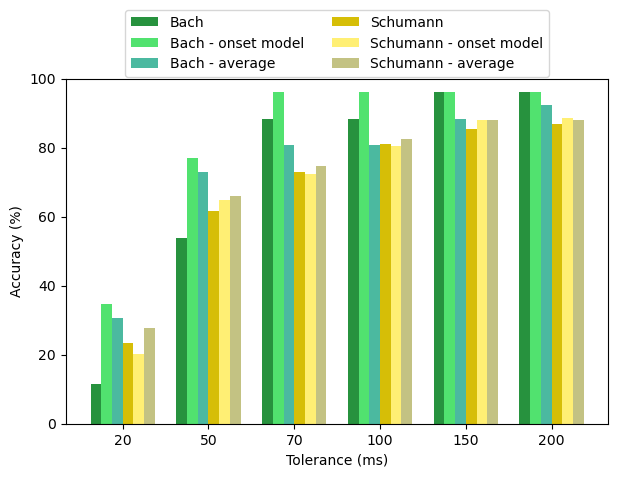

In [6]:
tolerances = t
accuracies = {
    'Bach': bachscores,
    'Bach - onset model': bachonsetscores,
    'Bach - average': bachaveragescores,
    'Schumann': schumannscores,
    'Schumann - onset model': schumannonsetscores,
    'Schumann - average': schumannaveragescores
}


colors = {
    'Bach': '#27923e',
    'Bach - onset model': '#51e26f',
    'Bach - average': '#4bb9a0',
    'Schumann': '#d6be07',
    'Schumann - onset model': '#ffef74',
    'Schumann - average': '#c3c283'
}

print(bachscores)

x = np.arange(0, len(tolerances) * 2, 2)  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(top=0.80)

for prediction, score in accuracies.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, score, width, label=prediction, color=colors[prediction])
    # ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Tolerance (ms)')
# ax.set_title('Accuracy of Sheet Music Follower at Different Tolerances', pad=60)
ax.set_xticks(x + width*2.5, tolerances)
ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.22))
ax.set_ylim(0, 100)

plt.show()